In [1]:
# on Height-Weight Dataset
# importing packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Data Loading

df =  pd.read_csv('height-weight.csv')
print(df.head())
print(df.tail())
df.sample(4)

   Weight  Height
0      45     120
1      58     135
2      48     123
3      60     145
4      70     160
    Weight  Height
18      76     150
19      87     167
20      45     129
21      56     140
22      72     160


,Weight,Height
19,87,167
6,80,163
9,78,170
5,78,162


In [3]:
# Shape of the DataFrame
df.shape

(23, 2)

In [4]:
# Columns of the DataFrame
df.columns

Index(['Weight', 'Height'], dtype='str')

In [5]:
# Information about the DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


In [6]:
# Description of the DataFrame
df.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


In [7]:
df.isna().sum()

Weight    0
Height    0
dtype: int64

In [8]:
df.isnull().sum()

Weight    0
Height    0
dtype: int64

In [9]:
# Duplicates in the DataFrame
df.duplicated().sum()

np.int64(1)

In [10]:
# If duplicate then drop it (inplace = True) does not return a new DataFrame, it modifies the existing DataFrame.
df.drop_duplicates(inplace=True)

In [11]:
# Check if the duplicates are dropped or not
df.duplicated().sum()

np.int64(0)

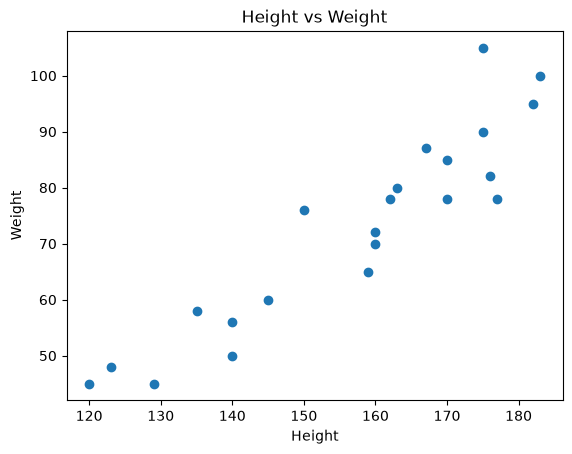

In [12]:
# EDA (Exploratory Data Analysis)
plt.scatter(df['Height'], df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight')
plt.show()

In [13]:
X = df[['Weight']]
y = df[['Height']]

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train)
print(y_train)

    Weight
5       78
21      56
12     105
3       60
4       70
18      76
13     100
19      87
17      65
2       48
9       78
22      72
7       90
10      82
15      78
20      45
6       80
    Height
5      162
21     140
12     175
3      145
4      160
18     150
13     183
19     167
17     159
2      123
9      170
22     160
7      175
10     176
15     177
20     129
6      163


In [43]:
# scaling the data using StandardScaler

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(X_train_scaled)
print(X_test_scaled)


[[ 0.20608301]
 [-1.17025708]
 [ 1.89522766]
 [-0.92001342]
 [-0.2944043 ]
 [ 0.08096118]
 [ 1.58242309]
 [ 0.76913122]
 [-0.60720886]
 [-1.67074438]
 [ 0.20608301]
 [-0.16928247]
 [ 0.95681396]
 [ 0.45632666]
 [ 0.20608301]
 [-1.85842712]
 [ 0.33120483]]
[[-1.85842712]
 [ 0.6440094 ]
 [ 1.26961853]
 [-1.04513525]
 [-1.54562255]]


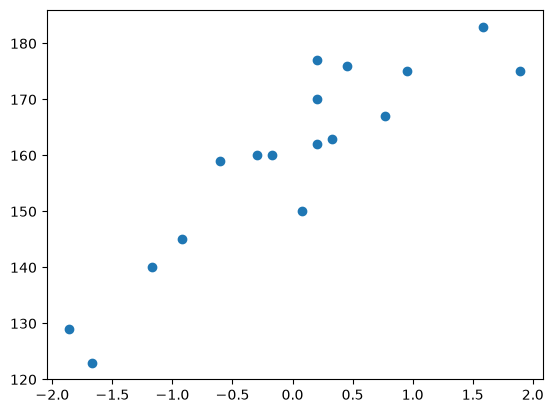

In [44]:
plt.scatter(X_train_scaled, y_train)

In [45]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[15.02]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[159.65]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.12]


In [ ]:
y_predict = model.predict(X_test_scaled)

In [51]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_predict)
mse = mean_squared_error(y_test, y_predict)
rmse = np.sqrt(mse)

print(mae)
print(mse)
print(rmse)

5.645752979414942
48.401802156635064
6.957140372066318
